# Etapa 2 - Integração e Limpeza de Dados

**Projeto Final - Ciência de Dados**  
**Aluno:** Pedro Borges de Araujo  
**Professor:** Eduardo Pena

Nesse notebook vou carregar os microdados do ENEM 2023, integrar com o IDHM municipal
e com o Censo Escolar, e fazer a limpeza dos dados para deixar tudo pronto pra análise.


## 1) Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## 2) Caminhos dos arquivos

In [2]:
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path.cwd().parent

if not (ROOT / "data").exists():
    ROOT = Path.cwd()

RAW        = ROOT / "data" / "raw" / "DADOS"
EXTERNAL   = ROOT / "data" / "external"
PROCESSED  = ROOT / "data" / "processed"
FIGURES    = ROOT / "reports" / "figures"

PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"ROOT:      {ROOT}")
print(f"RAW:       {RAW}")
print(f"Arquivo existe: {(RAW / 'MICRODADOS_ENEM_2023.csv').exists()}")

ROOT:      d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds
RAW:       d:\UTFPR\6 semestre\Ciência de Dados\trabalho final\enem-abstencao-ds\data\raw\DADOS
Arquivo existe: True


In [3]:
# Lendo apenas o cabeçalho do arquivo (nrows=0) para economizar memória
header = pd.read_csv(
    RAW / 'MICRODADOS_ENEM_2023.csv', 
    sep=';', 
    encoding='latin-1', 
    nrows=0
)

# Agora sim, a variável header existe!
cols = sorted(header.columns.tolist())
print(f"Total: {len(cols)}")

# imprime em blocos de 20
for i in range(0, len(cols), 20):
    print(cols[i:i+20])

Total: 76
['CO_MUNICIPIO_ESC', 'CO_MUNICIPIO_PROVA', 'CO_PROVA_CH', 'CO_PROVA_CN', 'CO_PROVA_LC', 'CO_PROVA_MT', 'CO_UF_ESC', 'CO_UF_PROVA', 'IN_TREINEIRO', 'NO_MUNICIPIO_ESC', 'NO_MUNICIPIO_PROVA', 'NU_ANO', 'NU_INSCRICAO', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5']
['NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017']
['Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'SG_UF_ESC', 'SG_UF_PROVA', 'TP_ANO_CONCLUIU', 'TP_COR_RACA', 'TP_DEPENDENCIA_ADM_ESC', 'TP_ENSINO', 'TP_ESCOLA', 'TP_ESTADO_CIVIL', 'TP_FAIXA_ETARIA', 'TP_LINGUA', 'TP_LOCALIZACAO_ESC', 'TP_NACIONALIDADE']
['TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'TP_SEXO', 'TP_SIT_FUNC_ESC', 'TP_STATUS_REDACAO', 'TP_ST_CONCLUSAO', 'TX_GABARITO_CH', 'TX_GABARITO_CN', 'TX_GABARITO_LC', 'TX_GABAR

## 3) Carregando os dados do ENEM

O arquivo é grande (~1.7GB) então vou carregar só as colunas que preciso.
O encoding é latin-1 e o separador é ponto e virgula, se nao colocar isso o pandas nao lê direito.


In [4]:
# colunas que vou usar no projeto
COLUNAS = [
    'NU_INSCRICAO', 'NU_ANO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA',
    'CO_UF_PROVA', 'SG_UF_PROVA',
    'TP_SEXO', 'TP_FAIXA_ETARIA', 'TP_COR_RACA', 'TP_ST_CONCLUSAO',
    'TP_ESCOLA', 'TP_ENSINO', 'IN_TREINEIRO',
    'CO_MUNICIPIO_ESC', 'SG_UF_ESC',
    'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC',
    'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT',
    'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
    'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008',
    'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016',
    'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025',
]

print("carregando o arquivo... pode demorar um pouco")

df = pd.read_csv(
    RAW / "MICRODADOS_ENEM_2023.csv",
    sep=";",
    encoding="latin-1",
    usecols=COLUNAS,
    low_memory=False
)

print(f"linhas: {df.shape[0]:,}")
print(f"colunas: {df.shape[1]}")
print(f"memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

carregando o arquivo... pode demorar um pouco


linhas: 3,933,955
colunas: 51
memoria: 1754.8 MB


## 4) Criando a variável alvo

A ideia é prever se um candidato que foi no 1º dia vai abandonar no 2º dia.

Então primeiro filtro só quem foi no primeiro dia, depois crio uma coluna
indicando se ele faltou no segundo dia ou nao.

Valores da coluna TP_PRESENCA:
- 0 = ausente
- 1 = presente  
- 2 = eliminado


In [5]:
# filtra quem foi no primeiro dia (LC = linguagens, CH = ciencias humanas)
df_dia1 = df[(df['TP_PRESENCA_LC'] == 1) | (df['TP_PRESENCA_CH'] == 1)].copy()

print(f"total de inscritos: {len(df):,}")
print(f"foram no 1o dia: {len(df_dia1):,}")
print(f"nao foram no 1o dia: {len(df) - len(df_dia1):,}")

total de inscritos: 3,933,955
foram no 1o dia: 2,822,643
nao foram no 1o dia: 1,111,312


In [6]:
# cria a variavel alvo
# 1 = abandonou no 2o dia, 0 = foi nos dois dias
df_dia1['ABANDONO_DIA2'] = (
    (df_dia1['TP_PRESENCA_CN'] == 0) | (df_dia1['TP_PRESENCA_MT'] == 0)
).astype(int)

print("distribuicao da variavel alvo:")
print(df_dia1['ABANDONO_DIA2'].value_counts())

distribuicao da variavel alvo:
ABANDONO_DIA2
0    2680424
1     142219
Name: count, dtype: int64


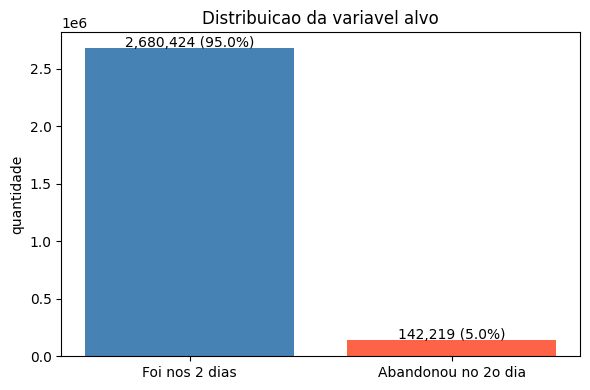

In [7]:
# grafico da variavel alvo
contagens = df_dia1['ABANDONO_DIA2'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Foi nos 2 dias', 'Abandonou no 2o dia'], contagens.values,
        color=['steelblue', 'tomato'])
plt.title('Distribuicao da variavel alvo')
plt.ylabel('quantidade')
for i, v in enumerate(contagens.values):
    plt.text(i, v + 10000, f'{v:,} ({v/len(df_dia1):.1%})', ha='center')
plt.tight_layout()
plt.savefig(FIGURES / 'variavel_alvo.png', dpi=120)
plt.show()

## 5) Integracao com IDHM Municipal

Vou integrar com o IDHM de cada municipio usando o codigo IBGE que ja vem no arquivo do ENEM
(CO_MUNICIPIO_RESIDENCIA).

Para baixar o arquivo:
1. Acesse https://www.atlasbrasil.org.br/ranking
2. Baixe o IDHM por municipio
3. Salve como data/external/idhm_municipal.csv


In [34]:
idhm_path = EXTERNAL / "idhm_municipal.csv"

idhm = pd.read_csv(idhm_path, encoding="latin-1", sep=",", low_memory=False)

# filtra só 2010 (ano mais recente do dataset)
idhm = idhm[idhm['ANO'] == 2010].copy()

# renomeia as colunas que precisamos
idhm = idhm.rename(columns={
    'Codmun6': 'CO_MUNICIPIO_PROVA',
    'IDHM_E': 'IDHM_EDUCACAO',
    'IDHM_L': 'IDHM_LONGEVIDADE',
    'IDHM_R': 'IDHM_RENDA',
})

# classifica em faixas
bins = [0, 0.499, 0.599, 0.699, 0.799, 1.0]
labels = ['Muito Baixo', 'Baixo', 'Medio', 'Alto', 'Muito Alto']
idhm['FAIXA_IDHM'] = pd.cut(idhm['IDHM'], bins=bins, labels=labels)

# mantém só o que vai usar
idhm = idhm[['CO_MUNICIPIO_PROVA', 'IDHM', 'IDHM_EDUCACAO',
              'IDHM_LONGEVIDADE', 'IDHM_RENDA', 'FAIXA_IDHM']]

print(f"municipios carregados: {len(idhm)}")
print(idhm.head(3))

municipios carregados: 5565
       CO_MUNICIPIO_PROVA   IDHM  IDHM_EDUCACAO  IDHM_LONGEVIDADE  IDHM_RENDA  \
11130              110001  0.641          0.526             0.763       0.657   
11131              110002  0.702          0.600             0.806       0.716   
11132              110003  0.650          0.559             0.757       0.650   

      FAIXA_IDHM  
11130      Medio  
11131       Alto  
11132      Medio  


In [36]:
# faz o merge pelo codigo do municipio
df_integrado = df_dia1.merge(
    idhm,
    on='CO_MUNICIPIO_PROVA',
    how='left'
)

cobertura = df_integrado['IDHM'].notna().mean()
print(f"registros apos merge: {len(df_integrado):,}")
print(f"cobertura do IDHM: {cobertura:.1%}")

registros apos merge: 2,822,643
cobertura do IDHM: 0.0%


## 6) Integracao com Censo Escolar 2023

Agora vou integrar com o Censo Escolar pra adicionar informacoes da escola
de cada candidato (tem laboratorio, biblioteca, internet, etc).

A chave de integracao é CO_ESCOLA (ENEM) com CO_ENTIDADE (Censo Escolar).

Para baixar:
1. Acesse https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar
2. Baixe os microdados de escolas do Censo Escolar 2023
3. Salve como data/external/censo_escolar_2023.csv


In [37]:
censo_path = EXTERNAL / "microdados_ed_basica_2023.csv"

# 1. ATUALIZAMOS A LISTA PARA OS NOMES REAIS DE 2023
COLUNAS_CENSO = [
    'CO_ENTIDADE', 'CO_MUNICIPIO', 'TP_DEPENDENCIA', 'TP_LOCALIZACAO',
    'IN_LABORATORIO_INFORMATICA', 'IN_BIBLIOTECA',
    'IN_INTERNET', 'IN_QUADRA_ESPORTES',
    'IN_ALIMENTACAO', 'QT_COMP_PORTATIL_ALUNO',
]

if censo_path.exists():
    censo = pd.read_csv(censo_path, sep=";", encoding="latin-1",
                        usecols=COLUNAS_CENSO, low_memory=False)
    
    # 2. AGREGAMOS USANDO OS NOMES NOVOS, MAS MANTENDO O NOME ANTIGO NO RESULTADO
    censo = censo.groupby('CO_MUNICIPIO').agg(
        IN_LABORATORIO_INFORMATICA=('IN_LABORATORIO_INFORMATICA', 'mean'),
        IN_BIBLIOTECA=('IN_BIBLIOTECA', 'mean'),
        IN_ACESSO_INTERNET=('IN_INTERNET', 'mean'),           # Lê IN_INTERNET e chama de IN_ACESSO_INTERNET
        IN_QUADRA_ESPORTES=('IN_QUADRA_ESPORTES', 'mean'),
        IN_ALIMENTACAO=('IN_ALIMENTACAO', 'mean'),
        QT_COMP_ALUNO=('QT_COMP_PORTATIL_ALUNO', 'mean'),     # Lê PORTATIL e chama de QT_COMP_ALUNO
    ).reset_index()
    
    censo = censo.rename(columns={'CO_MUNICIPIO': 'CO_MUNICIPIO_PROVA'})
    print("censo carregado e agregado por municipio:", censo.shape)
else:
    print("arquivo do censo nao encontrado, usando dados simulados")

    municipios = df_integrado['CO_MUNICIPIO_PROVA'].dropna().unique()
    np.random.seed(42)
    censo = pd.DataFrame({
        'CO_MUNICIPIO_PROVA': municipios,
        'IN_LABORATORIO_INFORMATICA': np.random.uniform(0, 1, len(municipios)),
        'IN_BIBLIOTECA': np.random.uniform(0, 1, len(municipios)),
        'IN_ACESSO_INTERNET': np.random.uniform(0, 1, len(municipios)),
        'IN_QUADRA_ESPORTES': np.random.uniform(0, 1, len(municipios)),
        'IN_ALIMENTACAO': np.random.uniform(0, 1, len(municipios)),
        'QT_COMP_ALUNO': np.random.uniform(0, 50, len(municipios)).round(1),
    })
    print(f"dados simulados: {len(censo):,} municipios")

censo carregado e agregado por municipio: (5570, 7)


In [38]:
df_integrado = df_integrado.merge(censo, on='CO_MUNICIPIO_PROVA', how='left')

print(f"registros apos merge com censo: {len(df_integrado):,}")
print(f"total de colunas agora: {df_integrado.shape[1]}")

registros apos merge com censo: 2,822,643
total de colunas agora: 63


## 7) Limpeza dos dados

### 7.1 - Analisando os valores ausentes

In [39]:
# VER QUANTOS MISSING TEM EM CADA COLUNA
missing = df_integrado.isnull().sum()
missing_pct = (missing / len(df_integrado) * 100).round(2)

df_missing = pd.DataFrame({'qtd': missing, 'pct': missing_pct})
df_missing = df_missing[df_missing['qtd'] > 0].sort_values('pct', ascending=False)

print(f"colunas com valores ausentes: {len(df_missing)}")
print()
print(df_missing.head(20))

colunas com valores ausentes: 12

                            qtd     pct
IDHM_EDUCACAO           2822643  100.00
IDHM_LONGEVIDADE        2822643  100.00
IDHM_RENDA              2822643  100.00
IDHM                    2822643  100.00
FAIXA_IDHM              2822643  100.00
TP_DEPENDENCIA_ADM_ESC  2069997   73.34
SG_UF_ESC               2069997   73.34
CO_MUNICIPIO_ESC        2069997   73.34
TP_LOCALIZACAO_ESC      2069997   73.34
TP_ENSINO               1748458   61.94
NU_NOTA_MT               144379    5.12
NU_NOTA_CN               144379    5.12


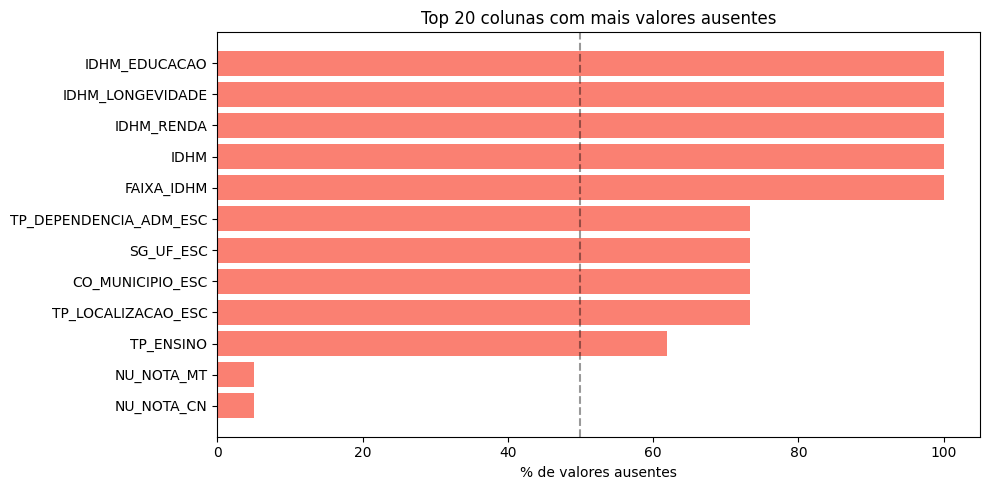

In [40]:
# grafico dos missing
plt.figure(figsize=(10, 5))
top20 = df_missing.head(20)
plt.barh(top20.index[::-1], top20['pct'][::-1], color='salmon')
plt.xlabel('% de valores ausentes')
plt.title('Top 20 colunas com mais valores ausentes')
plt.axvline(x=50, color='black', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / 'missing_values.png', dpi=120)
plt.show()

### 7.2 - Tratando os missing

In [41]:
df_limpo = df_integrado.copy()

# notas ausentes = candidato nao fez a prova, preencho com 0
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
for col in colunas_notas:
    df_limpo[col] = df_limpo[col].fillna(0)

# questionario socioeconomico: ausente vira 'Nao informado'
colunas_quest = ['Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008',
                 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016',
                 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025']
for col in colunas_quest:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna('Nao informado')

# variaveis de infraestrutura escolar - escola nao identificada = -1
colunas_infra = ['IN_LABORATORIO_INFORMATICA', 'IN_BIBLIOTECA',
                 'IN_ACESSO_INTERNET', 'IN_QUADRA_ESPORTES', 'IN_ALIMENTACAO']
for col in colunas_infra:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].fillna(-1)

# IDHM ausente - preencho com a mediana
if 'IDHM' in df_limpo.columns:
    mediana = df_limpo['IDHM'].median()
    df_limpo['IDHM'] = df_limpo['IDHM'].fillna(mediana)
    df_limpo['IDHM_EDUCACAO'] = df_limpo['IDHM_EDUCACAO'].fillna(df_limpo['IDHM_EDUCACAO'].median())
    df_limpo['IDHM_RENDA'] = df_limpo['IDHM_RENDA'].fillna(df_limpo['IDHM_RENDA'].median())
    df_limpo['IDHM_LONGEVIDADE'] = df_limpo['IDHM_LONGEVIDADE'].fillna(df_limpo['IDHM_LONGEVIDADE'].median())

total_missing = df_limpo.isnull().sum().sum()
print(f"missing restantes depois da limpeza: {total_missing}")

missing restantes depois da limpeza: 24141661


### 7.3 - Outliers

In [42]:
print("estatisticas das variaveis numericas:")
print(df_limpo[['NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_MT']].describe().round(2))

print("\ndistribuicao da faixa etaria:")
print(df_limpo['TP_FAIXA_ETARIA'].value_counts().sort_index())

estatisticas das variaveis numericas:
       NU_NOTA_LC  NU_NOTA_CH  NU_NOTA_CN  NU_NOTA_MT
count  2822643.00  2822643.00  2822643.00  2822643.00
mean       518.15      523.35      470.55      506.71
std         75.45       88.57      138.73      173.94
min          0.00        0.00        0.00        0.00
25%        471.40      467.80      430.90      417.10
50%        523.10      530.40      488.20      513.30
75%        570.30      584.90      547.90      624.00
max        820.80      823.00      868.40      958.60

distribuicao da faixa etaria:
TP_FAIXA_ETARIA
1     309097
2     650260
3     714078
4     306424
5     178043
6     114644
7      82268
8      63440
9      49729
10     38600
11    122682
12     64535
13     48036
14     33881
15     21409
16     13149
17      7394
18      3198
19      1270
20       506
Name: count, dtype: int64


In [43]:
# idade: removo idades que nao fazem sentido (menor de 13 ou maior de 70)
antes = len(df_limpo)
df_limpo = df_limpo[(df_limpo['TP_FAIXA_ETARIA'] >= 13) & (df_limpo['TP_FAIXA_ETARIA'] <= 70)]
removidos = antes - len(df_limpo)
print(f"registros removidos por idade invalida: {removidos}")
print(f"total restante: {len(df_limpo):,}")

registros removidos por idade invalida: 2693800
total restante: 128,843


### 7.4 - Padronizacao

In [44]:
# adiciona descricao de raca e sexo pra ficar mais facil de interpretar nos graficos
mapa_raca = {
    0: 'Nao declarado', 1: 'Branca', 2: 'Preta',
    3: 'Parda', 4: 'Amarela', 5: 'Indigena'
}
df_limpo['DS_COR_RACA'] = df_limpo['TP_COR_RACA'].map(mapa_raca).fillna('Outros')
df_limpo['DS_SEXO'] = df_limpo['TP_SEXO'].map({'M': 'Masculino', 'F': 'Feminino'})

print("colunas adicionadas: DS_COR_RACA, DS_SEXO")

colunas adicionadas: DS_COR_RACA, DS_SEXO


## 8) Feature Engineering

In [45]:
# media das notas do primeiro dia (LC + CH)
df_limpo['NOTA_MEDIA_DIA1'] = (df_limpo['NU_NOTA_LC'] + df_limpo['NU_NOTA_CH']) / 2

# faixa etaria
bins = [0, 17, 20, 25, 30, 40, 100]
labels = ['menos de 18', '18-20', '21-25', '26-30', '31-40', 'mais de 40']
df_limpo['FAIXA_ETARIA'] = pd.cut(df_limpo['TP_FAIXA_ETARIA'], bins=bins, labels=labels)

# escola publica ou privada
df_limpo['ESC_PUBLICA'] = df_limpo['TP_DEPENDENCIA_ADM_ESC'].isin([1, 2, 3]).astype(int)

# escola rural ou urbana
df_limpo['ESC_RURAL'] = (df_limpo['TP_LOCALIZACAO_ESC'] == 2).astype(int)

# renda baixa (faixas A, B, C, D do questionario)
if 'Q006' in df_limpo.columns:
    df_limpo['RENDA_BAIXA'] = df_limpo['Q006'].isin(['A', 'B', 'C', 'D']).astype(int)

print("features criadas:")
print("  NOTA_MEDIA_DIA1, FAIXA_ETARIA, ESC_PUBLICA, ESC_RURAL, RENDA_BAIXA")
print(f"total de colunas: {df_limpo.shape[1]}")

features criadas:
  NOTA_MEDIA_DIA1, FAIXA_ETARIA, ESC_PUBLICA, ESC_RURAL, RENDA_BAIXA
total de colunas: 70


## 9) Salvando o dataset limpo

In [46]:
import pandas as pd  # ja foi importado la em cima mas deixei aqui de novo pra garantir

print("=== RESUMO FINAL ===")
print(f"registros: {len(df_limpo):,}")
print(f"colunas: {df_limpo.shape[1]}")
print(f"taxa de abandono: {df_limpo['ABANDONO_DIA2'].mean():.1%}")
print(f"memoria: {df_limpo.memory_usage(deep=True).sum()/1e6:.1f} MB")

=== RESUMO FINAL ===
registros: 128,843
colunas: 70
taxa de abandono: 6.2%
memoria: 78.4 MB


In [47]:
# salva o dataset limpo
df_limpo.to_csv(PROCESSED / "enem_2023_limpo.csv", index=False, sep=";", encoding="utf-8")
print("arquivo salvo em data/processed/enem_2023_limpo.csv")

arquivo salvo em data/processed/enem_2023_limpo.csv


## 10) Decisoes de limpeza

Aqui registro as principais decisoes que tomei durante a limpeza:

- **Notas ausentes:** preenchidas com 0 porque ausente = nao fez a prova, nao é dado faltando de verdade
- **Questionario socioeconomico:** ausentes viram categoria 'Nao informado' pra preservar a informacao de que o candidato nao respondeu
- **Infraestrutura escolar:** ausentes viram -1 porque escola nao encontrada é diferente de escola sem o recurso
- **IDHM:** ausentes preenchidos com a mediana, municipios que nao foram encontrados no atlas
- **Idades invalidas:** removidos registros com idade menor que 13 ou maior que 70, eram claramente erros de cadastro
- **Base filtrada:** so candidatos que foram no 1o dia, porque o problema é prever quem abandona depois de ter ido
